In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery,reward_schedule = (100,-50,-0))

In [6]:
def extract_vars(env):

    n_s = env.observation_space.n
    n_a = env.action_space.n
    
    P_mat = np.zeros((n_s, n_a, n_s))

    R_mat = np.zeros((n_s, n_a, n_s))
    
    for s in range(n_s):
        for a in range(n_a):
            for prob, next_s, reward, something in env.unwrapped.P[s][a]:
                P_mat[s, a, next_s] += prob
                R_mat[s, a, next_s] += reward
                
    return P_mat, R_mat, n_s, n_a

In [7]:
def value_iteration(P, R, max_iter = 1000, gamma = 0.90, theta = 1e-8):
    n_s, n_a, _ = P.shape #getting number of states and actions from P
    V = np.zeros(n_s) #each state has a value, initialize to zero in start
    for i in range(max_iter):
        V_new = np.zeros(n_s) #intialize new state values for now as 0
        for s in range(n_s):
            Q_sa = np.zeros(n_a) #action value for each state action pair
            for a in range(n_a):
                Q_sa[a] = np.sum(P[s, a, :] * (R[s, a, :] + gamma * V)) #bellmann eq
            V_new[s] = np.max(Q_sa) #update value of state s to max action value
        if np.max(np.abs(V - V_new)) < theta:
                V = V_new
                print(f"Value function converged at iteration {i+1}")
                break
                
        V = V_new
    policy = np.zeros(n_s, dtype=int) #initialize policy to take action 0 in all states
    for s in range(n_s):
        Q_sa = np.zeros(n_a) #action values for actions from state s (held fixed)
        for a in range(n_a):
            Q_sa[a] = np.sum(P[s, a, :] * (R[s, a, :] + gamma * V)) #bellmann eq
        policy[s] = np.argmax(Q_sa) #update policy to take action with max action value
    return policy

In [8]:
def policy_iteration_using_bellmann(P,R,gamma = 0.90, max_iter = 100, policy_eval_iter = 1000,theta = 1e-8):
    n_s, n_a, _ = P.shape
    policy = np.zeros(n_s, dtype=int) #initially 0
    for i in range(max_iter):
        #Policy evaluation step
        V = np.zeros(n_s) #initialize state values to zero
        for j in range(policy_eval_iter):

            V_new = np.zeros(n_s) #intialize new state values for now as 0
            for s in range(n_s):
                Q_sa = np.zeros(n_a) #action value for each state action pair
                for a in range(n_a):
                    Q_sa[a] = np.sum(P[s, a, :] * (R[s, a, :] + gamma * V)) #belllmann eq
                V_new[s] = Q_sa[policy[s]]  #update value of state s according to policy
            if np.max(np.abs(V - V_new)) < theta:
                V = V_new
                break
            V = V_new
        #Policy improvement step
        new_policy = np.zeros(n_s, dtype=int)
        for s in range(n_s):
            Q_sa = np.zeros(n_a) #action values for actions from state s (held fixed)
            for a in range(n_a):
                Q_sa[a] = np.sum(P[s, a, :] * (R[s, a, :] + gamma * V)) #bellmann eq
            new_policy[s] = np.argmax(Q_sa) #update policy to take action with max action value
        if np.array_equal(policy, new_policy):
            print(f"Policy converged at iteration {i+1}")
            break
        policy = new_policy
    return policy

In [9]:
def policy_iteration_using_matrix_inversion(P, R, gamma=0.90, max_iter=100,theta=1e-8):
    n_s, n_a, _ = P.shape
    policy = np.zeros(n_s, dtype=int) # initially 0
    
    for i in range(max_iter):
        # Policy evaluation step
        P_pi = np.zeros((n_s, n_s))
        R_pi = np.zeros(n_s)
        
        # Finding P_pi and R_pi according to the current policy (probability of going to state s' from state s under policy pi and expected reward for taking action according to policy in state s)
        for s in range(n_s):
            a = policy[s]
            P_pi[s, :] = P[s, a, :]
            # Expected reward for taking action 'a' in state 's'
            R_pi[s] = np.sum(P[s, a, :] * R[s, a, :]) 
            
        A = np.eye(n_s) - gamma * P_pi
        V = np.linalg.solve(A, R_pi) #solving using matrix
        
        # Policy improvement step
        new_policy = np.zeros(n_s, dtype=int)
        for s in range(n_s):
            Q_sa = np.zeros(n_a) # action values for actions from state s (holding s fixed)
            for a in range(n_a):
                Q_sa[a] = np.sum(P[s, a, :] * (R[s, a, :] + gamma * V)) # bellman eq
            new_policy[s] = np.argmax(Q_sa) # update policy to take action with max action value
        if np.array_equal(policy, new_policy):
            print(f"Policy converged at iteration {i+1}")
            break
        policy = new_policy
            
    return policy
import time


In [10]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()


In [11]:
env = build_env(slippery=False)
P, R, n_s, n_a = extract_vars(env)


Policy converged at iteration 13


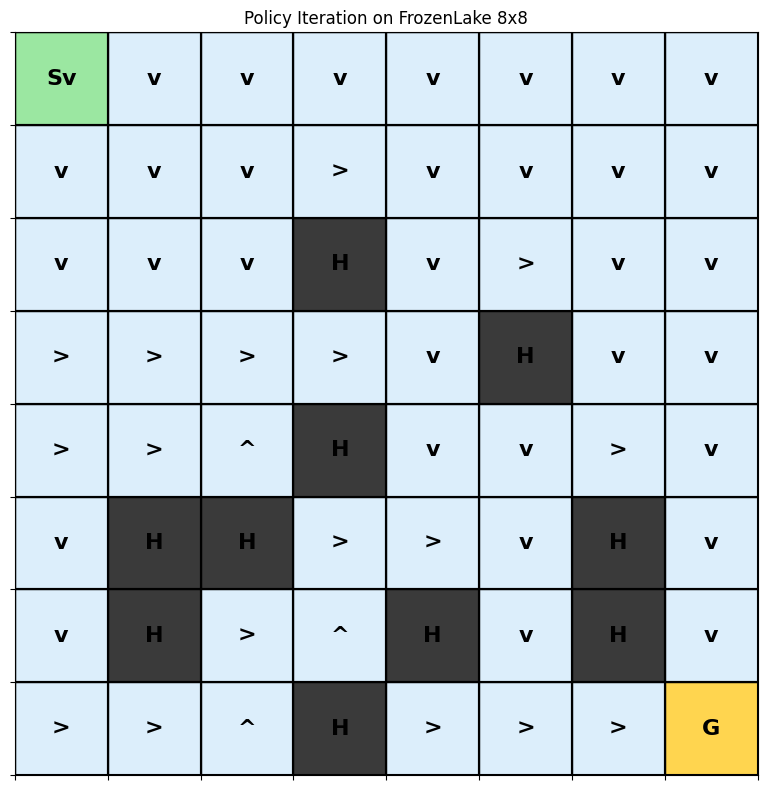

In [12]:
pi_policy = policy_iteration_using_bellmann(P, R)
plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")

Value function converged at iteration 15


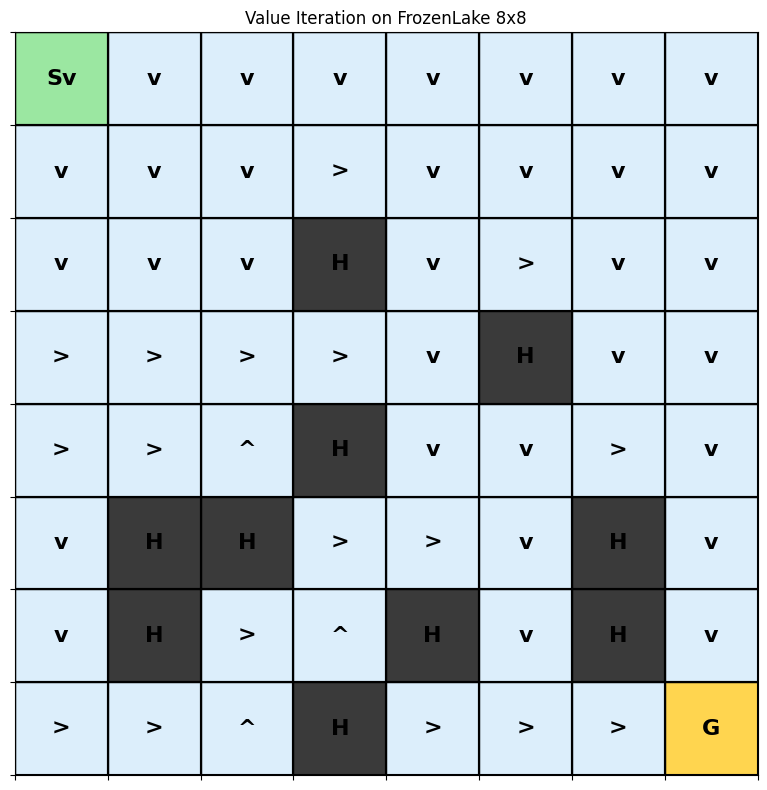

In [13]:
vi_policy = value_iteration(P, R)
plot_policy_on_frozen_lake(env, vi_policy, title="Value Iteration on FrozenLake 8x8")

Policy converged at iteration 13


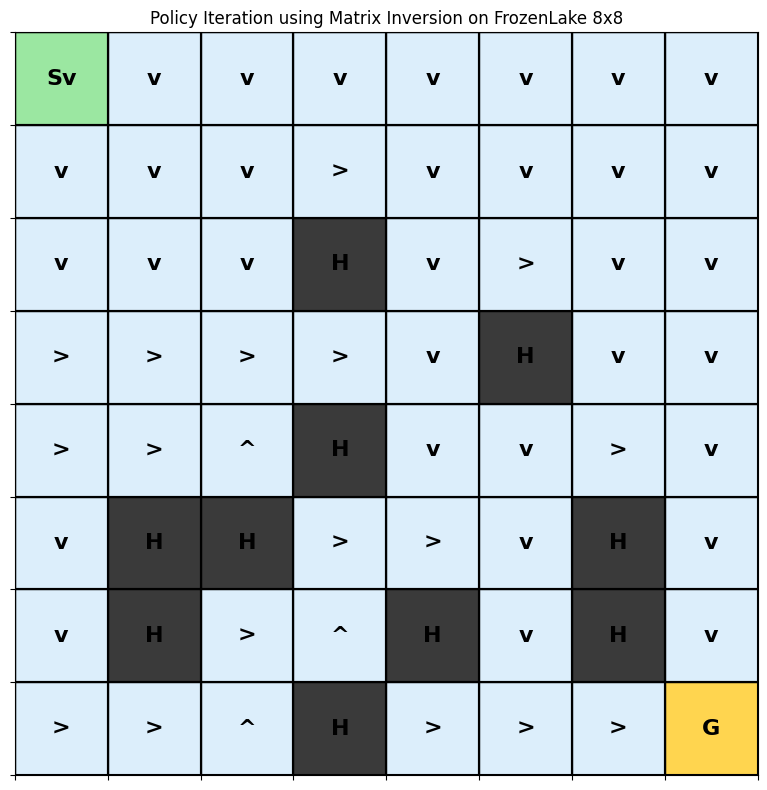

In [14]:
pi_matrix_policy = policy_iteration_using_matrix_inversion(P, R)
plot_policy_on_frozen_lake(env, pi_matrix_policy, title="Policy Iteration using Matrix Inversion on FrozenLake 8x8")